# K Nearest Neighbour 

" **You are the average of five people you spend your time with** "

Classifying data on the basis of eucledian distance from the marked clases

### Breast Cancer Dataset

In [34]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


In [35]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [36]:
df=pd.read_csv('breast-cancer.csv')

In [37]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [38]:
df.drop(columns=['id'],inplace=True)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [39]:
df.shape

(569, 31)

In [40]:
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test=train_test_split(df.iloc[:,1:],df.iloc[:,0],test_size=0.2,random_state=2,)

In [41]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [42]:
X_train.shape

(455, 30)

In [43]:
from sklearn.neighbors import KNeighborsClassifier
knn= KNeighborsClassifier(n_neighbors=5)

In [44]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [45]:
y_pred=knn.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score 
accuracy_score(y_test,y_pred)

0.9736842105263158

## How to select K?
- Depends on data however there are still methods to determine K        

### 1. Heuristic Approach - $$K=  \sqrt[2]{n} $$
- n = number of training observations only
- we generally avoid even values for K 

### 2. Experimentally - Cross Validation 
- lets say we have 1000 observation (800 - test , 200-train )
- Forming Multiple KNN Models ,(with different values of k)
- we will train all these models on our train data and check the accuracy score 
- and we will choose the model with best accuracy 

## Implementing Cross Validation

In [47]:
scores = []

for i in range(1,16):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    
    knn.fit(X_train,y_train)
    
    y_pred = knn.predict(X_test)

    scores.append(accuracy_score(y_test, y_pred))

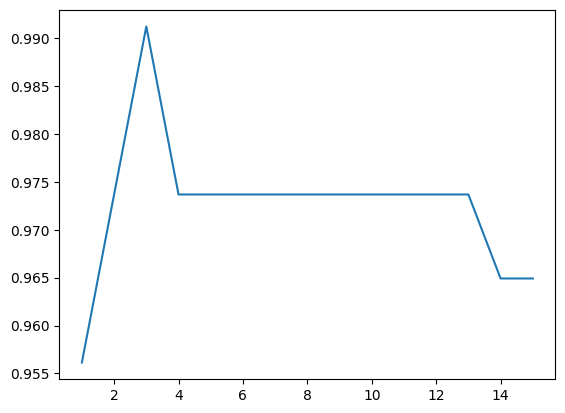

In [48]:
import matplotlib.pyplot as plt

plt.plot(range(1,16),scores)


## Overfitting and Underfitting 
- If value of k is low or k=1 , overfitting 
- if value of k is max, or k= n , underfitting (the class in majority dominates)

In [49]:
from matplotlib.colors import ListedColormap
from sklearn import neighbors, datasets
from ipywidgets import interact, fixed

def load_data():
    cancer = datasets.load_breast_cancer()
    return cancer

def plot_decision_boundaries(n_neighbors, data, labels):
    h = .02
    cmap_light = ListedColormap(['orange', 'blue'])
    cmap_bold = ListedColormap(['darkorange', 'darkblue'])

    clf = neighbors.KNeighborsClassifier(n_neighbors)
    clf.fit(data, labels)

    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f'2-Class classification (k = {n_neighbors})')
    plt.show()

cancer = load_data()

# Use only the first two features and standardize them.
X = StandardScaler().fit_transform(cancer.data[:, :2])
y = cancer.target

# Interactive widget
interact(plot_decision_boundaries, n_neighbors=(1, 20), data=fixed(X), labels=fixed(y));

interactive(children=(IntSlider(value=10, description='n_neighbors', max=20, min=1), Output()), _dom_classes=(…

## Failure Case :
1. KNN is a lazy learning technique - i.e. processing is done in the prediction phase and not in training phase 
    - So prediction is slow but training is fast 
    - in really large datasets lets say 5 lakh observations, this increases the latency of services in production
2. High dimensional Data - Curse of Dimmensionality 
    - in higher dimmension due to curse of dimmensionality , eucledian distance are not an apt measure of two points being closely linked
    - our entire algorithm works on distances so it fails 
3. Outliers
    - its not good at handling outliers
4. Non Homogenous Feature Scales 
    - Exp | Salary | fire
    - here we need to scale our data points as it does not work well with data point which are not in same range of scale
5. Imabalanced Datasets
    - Fraud detection cases 
6. Not good for inference 
    - Can not tell the importance of features about their contribution to two points being similar

## Decision Surface

- MLextend library plots the decision surface 